# PHẦN 1: TIỀN XỬ LÝ DỮ LIỆU & CHUẨN HÓA MIN-MAX (PREPROCESSING & NORMALIZATION)
Nội dung: Đọc dữ liệu thô, làm sạch, mã hóa phân loại (One-Hot), chuẩn hóa Min-Max [0, 1] và xuất CSDL SQLite `data/diabetes_pipeline.db`.

## I. Data understanding

### 1. Đọc dữ liệu

In [1]:
import pandas as pd
import joblib
import os
import sqlite3

# Tự động tìm vị trí tệp dữ liệu linh hoạt khi chạy trong thư mục code/ hoặc ở thư mục gốc
data_candidates = ['../data/diabetes_dataset.csv', 'data/diabetes_dataset.csv', '../diabetes_dataset.csv', 'diabetes_dataset.csv']
url = next((p for p in data_candidates if os.path.exists(p)), '../data/diabetes_dataset.csv')
data = pd.read_csv(url)
print(f'Đọc dữ liệu thành công từ đường dẫn: {url}')

# Tự động tạo thư mục data/ chứa CSDL SQLite
db_dir = '../data' if os.path.exists('../data') or os.path.exists('..') else 'data'
os.makedirs(db_dir, exist_ok=True)
db_path = os.path.join(db_dir, 'diabetes_pipeline.db')
conn_sqlite = sqlite3.connect(db_path)
data.to_sql('raw_dataset', conn_sqlite, if_exists='replace', index=False)
print(f'Đã lưu bảng dữ liệu thô [raw_dataset] vào SQLite: {db_path}')


Đọc dữ liệu thành công từ đường dẫn: ../data/diabetes_dataset.csv
Đã lưu bảng dữ liệu thô [raw_dataset] vào SQLite: ../data\diabetes_pipeline.db


### 2. Xem 5 dòng đầu

In [2]:
data.head()

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


### 3. Xem kích thước

In [3]:
print(f"Kích thước dữ liệu: {data.shape[0]} dòng, {data.shape[1]} cột")

Kích thước dữ liệu: 100000 dòng, 31 cột


### 4. Danh sách các cột

In [4]:
list(data.columns)

['age',
 'gender',
 'ethnicity',
 'education_level',
 'income_level',
 'employment_status',
 'smoking_status',
 'alcohol_consumption_per_week',
 'physical_activity_minutes_per_week',
 'diet_score',
 'sleep_hours_per_day',
 'screen_time_hours_per_day',
 'family_history_diabetes',
 'hypertension_history',
 'cardiovascular_history',
 'bmi',
 'waist_to_hip_ratio',
 'systolic_bp',
 'diastolic_bp',
 'heart_rate',
 'cholesterol_total',
 'hdl_cholesterol',
 'ldl_cholesterol',
 'triglycerides',
 'glucose_fasting',
 'glucose_postprandial',
 'insulin_level',
 'hba1c',
 'diabetes_risk_score',
 'diabetes_stage',
 'diagnosed_diabetes']

### 5. Kiểu dữ liệu

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   gender                              100000 non-null  object 
 2   ethnicity                           100000 non-null  object 
 3   education_level                     100000 non-null  object 
 4   income_level                        100000 non-null  object 
 5   employment_status                   100000 non-null  object 
 6   smoking_status                      100000 non-null  object 
 7   alcohol_consumption_per_week        100000 non-null  int64  
 8   physical_activity_minutes_per_week  100000 non-null  int64  
 9   diet_score                          100000 non-null  float64
 10  sleep_hours_per_day                 100000 non-null  float64
 11  screen_time_hours_per_day  

### 6. Thống kê dữ liệu số

In [6]:
data.describe()

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,...,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diagnosed_diabetes
count,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50.12041,2.003670,118.911640,5.994787,6.997818,5.996468,0.219410,0.250800,0.079200,25.612653,...,185.978110,54.042790,103.000430,121.462650,111.11712,160.035050,9.061242,6.520776,30.222362,0.599980
std,15.60460,1.417779,84.409662,1.780954,1.094622,2.468406,0.413849,0.433476,0.270052,3.586705,...,32.013005,10.267374,33.390256,43.372619,13.59561,30.935472,4.954060,0.813921,9.061505,0.489904
min,18.00000,0.000000,0.000000,0.000000,3.000000,0.500000,0.000000,0.000000,0.000000,15.000000,...,100.000000,20.000000,50.000000,30.000000,60.00000,70.000000,2.000000,4.000000,2.700000,0.000000
25%,39.00000,1.000000,57.000000,4.800000,6.300000,4.300000,0.000000,0.000000,0.000000,23.200000,...,164.000000,47.000000,78.000000,91.000000,102.00000,139.000000,5.090000,5.970000,23.800000,0.000000
50%,50.00000,2.000000,100.000000,6.000000,7.000000,6.000000,0.000000,0.000000,0.000000,25.600000,...,186.000000,54.000000,102.000000,121.000000,111.00000,160.000000,8.790000,6.520000,29.000000,1.000000
75%,61.00000,3.000000,160.000000,7.200000,7.700000,7.700000,0.000000,1.000000,0.000000,28.000000,...,208.000000,61.000000,126.000000,151.000000,120.00000,181.000000,12.450000,7.070000,35.600000,1.000000
max,90.00000,10.000000,833.000000,10.000000,10.000000,16.800000,1.000000,1.000000,1.000000,39.200000,...,318.000000,98.000000,263.000000,344.000000,172.00000,287.000000,32.220000,9.800000,67.200000,1.000000


### 7. Thống kê dữ liệu phân loại

In [7]:
data.describe(include='object')

,gender,ethnicity,education_level,income_level,employment_status,smoking_status,diabetes_stage
count,100000,100000,100000,100000,100000,100000,100000
unique,3,5,4,5,4,3,5
top,Female,White,Highschool,Middle,Employed,Never,Type 2
freq,50216,44997,44891,35152,60175,59813,59774


## II. Data cleaning

### 1. Kiểm tra giá trị thiếu (Missing Values)

In [8]:
missing = pd.DataFrame({
    'Missing Values': data.isnull().sum(),
    'Percentage (%)': round(data.isnull().mean() * 100, 2)
})
if missing['Missing Values'].sum() == 0:
    print("Tuyệt vời! Không có giá trị thiếu (NaN) nào trong tập dữ liệu.")
else:
    display(missing[missing['Missing Values'] > 0])

Tuyệt vời! Không có giá trị thiếu (NaN) nào trong tập dữ liệu.


### 2. Kiểm tra dữ liệu trùng (Duplicate Records)

In [9]:
print(f"Số dòng trùng lặp: {data.duplicated().sum()}")

Số dòng trùng lặp: 0


### 3. Loại bỏ rò rỉ thông tin (Data Leakage) & Biến phái sinh (Giai đoạn 0)
Ta loại bỏ ngay 4 cột ra khỏi dữ liệu thô:
* `diagnosed_diabetes`: Kết quả chẩn đoán trước đó (Leakage trực tiếp).
* `diabetes_stage`: Giai đoạn tiểu đường (Hậu quả của đường huyết - Leakage).
* `glucose_postprandial`: Đường huyết sau ăn (Tương quan trực tiếp - Leakage).
* `diabetes_risk_score`: Điểm nguy cơ tiểu đường (Tổ hợp tuyến tính từ tuổi, BMI, tiền sử gia đình... gây đa cộng tuyến nghiêm trọng).

In [10]:
# Loại bỏ 4 cột leakage y khoa và biến phái sinh ở bước làm sạch ban đầu
cols_to_drop = ['diagnosed_diabetes', 'diabetes_stage', 'glucose_postprandial', 'diabetes_risk_score']
data = data.drop(columns=cols_to_drop)
print(f"Kích thước sau khi loại bỏ Leakage: {data.shape}")

Kích thước sau khi loại bỏ Leakage: (100000, 27)


### 4. Chia dữ liệu thành kiểu liên tục, nhị phân, categorical

In [11]:
numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns
binary_cols = []
continuous_cols = []
for col in numeric_cols:
    unique_values = sorted(data[col].dropna().unique())
    if unique_values == [0, 1]:
        binary_cols.append(col)
    else:
        continuous_cols.append(col)

categorical_cols = data.select_dtypes(include='object').columns
print("Biến liên tục:", continuous_cols)
print("Biến nhị phân:", binary_cols)
print("Biến chữ:", list(categorical_cols))

Biến liên tục: ['age', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides', 'glucose_fasting', 'insulin_level', 'hba1c']
Biến nhị phân: ['family_history_diabetes', 'hypertension_history', 'cardiovascular_history']
Biến chữ: ['gender', 'ethnicity', 'education_level', 'income_level', 'employment_status', 'smoking_status']


### 5. Kiểm tra outlier trên tập liên tục bằng Boxplot

**Nhận xét từ biểu đồ ngoại lai (Boxplot):**
* Nhìn vào biểu đồ hộp, ta thấy các biến số sinh học liên tục như BMI (xuất hiện nhiều giá trị cực đoan > 40), triglycerides (> 300) và huyết áp đều xuất hiện nhiều chấm đen ngoại lai kéo dài ở cả hai phía râu hộp.
* Việc có nhiều giá trị ngoại lai cực đoan này nếu để nguyên sẽ gây nhiễu rất lớn cho đường thẳng hồi quy OLS, kéo lệch đường hồi quy và làm tăng sai số dự báo tổng thể.

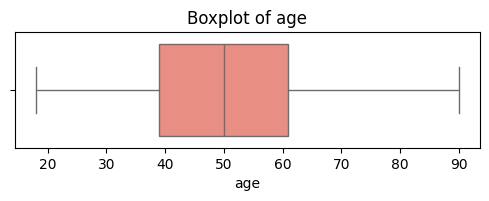

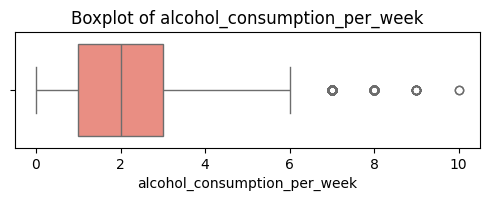

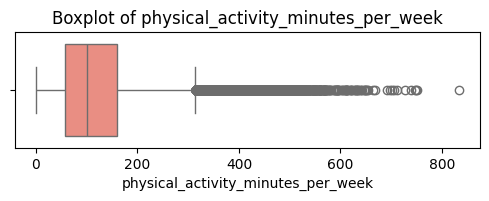

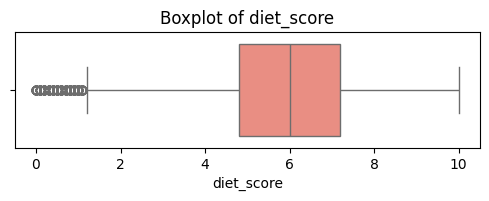

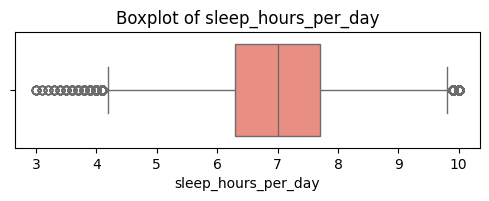

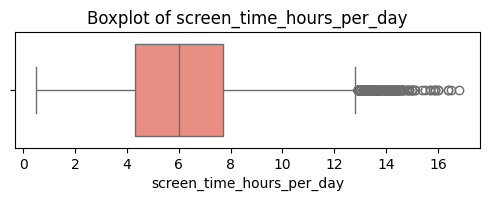

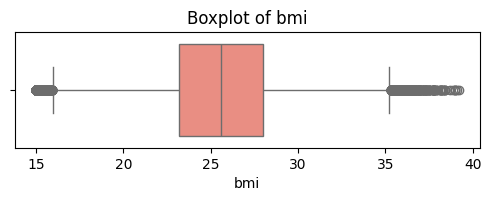

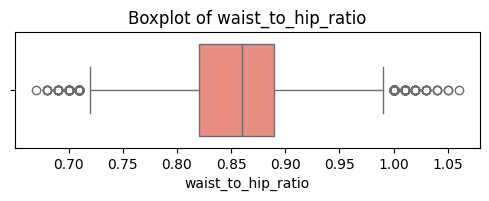

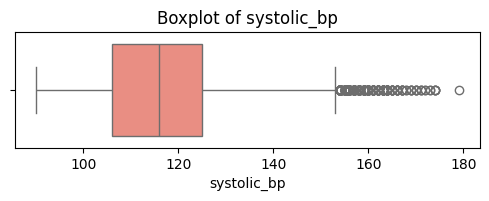

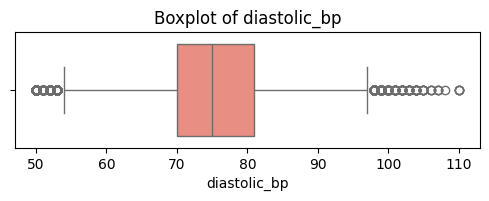

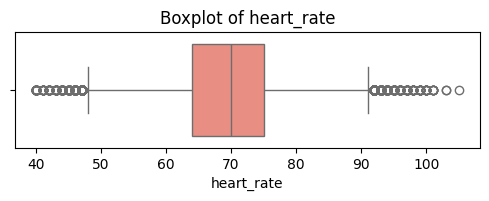

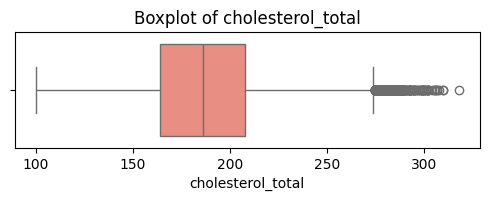

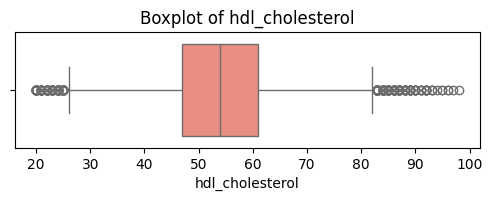

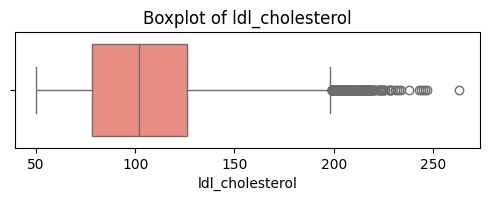

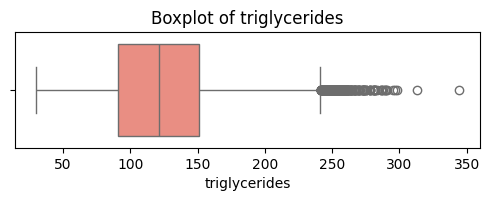

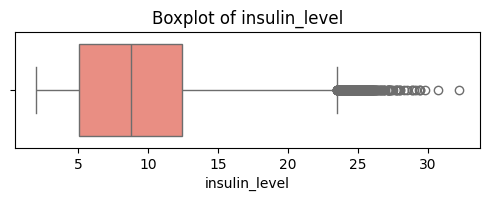

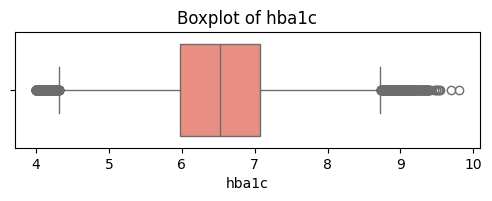

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
for col in continuous_cols:
    if col != 'glucose_fasting':
        plt.figure(figsize=(6,1.5))
        sns.boxplot(data=data, x=col, color='salmon')
        plt.title(f"Boxplot of {col}")
        plt.show()

### 6. Xử lý outlier bằng co đầu mút Capping 1% - 99% (Giai đoạn 1)

**Nhận xét về kết quả xử lý ngoại lai bằng Capping:**
* Ta áp dụng phương pháp co đầu mút Capping (Winsorization) ở ngưỡng 1% và 99%. Tất cả các giá trị dị biệt vượt ngoài ranh giới này được co về biên an toàn.
* Phương pháp này giúp triệt tiêu hoàn toàn ảnh hưởng của các điểm dị biệt nhiễu cho mô hình hồi quy OLS mà không cần xóa bỏ bất kỳ dòng dữ liệu bệnh nhân nào, đảm bảo bảo toàn 100% cỡ mẫu (100,000 dòng) phục vụ nghiên cứu.

In [13]:
import numpy as np
clean_data = data.copy()
target = 'glucose_fasting'
capping_cols = [col for col in continuous_cols if col != target]

for col in capping_cols:
    lower_limit = data[col].quantile(0.01)
    upper_limit = data[col].quantile(0.99)
    clean_data[col] = np.clip(data[col], lower_limit, upper_limit)

data = clean_data
print("Cập nhật dữ liệu sạch đã capping thành công!")

Cập nhật dữ liệu sạch đã capping thành công!


### 7. Vẽ biểu đồ phân phối sau khi xử lý Outlier

**Nhận xét biểu đồ phân phối sau khi Capping (Histogram):**
* Sau khi áp dụng Capping, biểu đồ phân phối của các biến liên tục đã được làm sạch phần đuôi ngoại lai kéo dài.
* Phân phối dữ liệu trông gọn gàng, bớt lệch hơn, giúp đáp ứng tốt hơn các giả định phân phối của mô hình hồi quy OLS và làm giảm sai số RMSE khi huấn luyện.

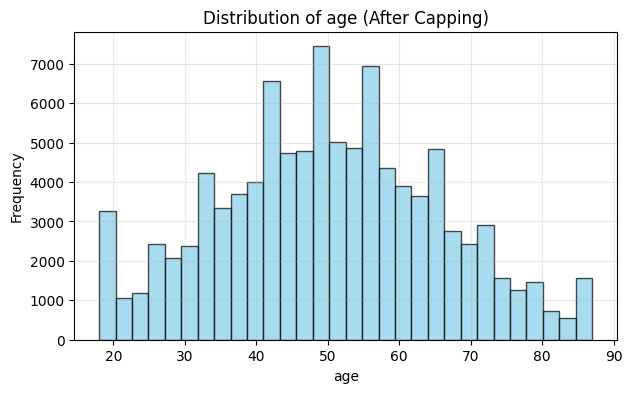

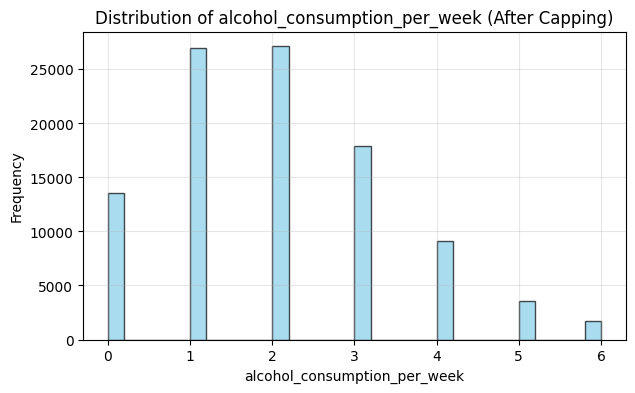

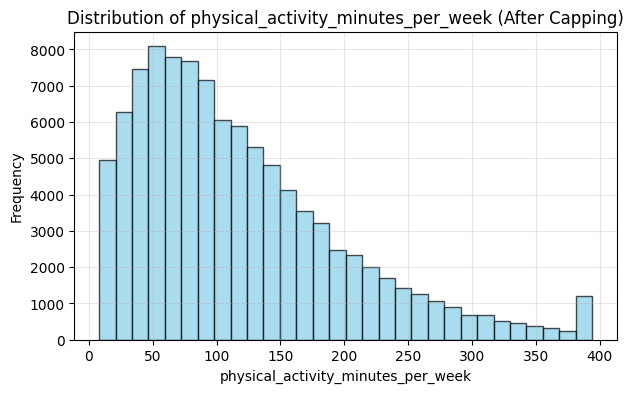

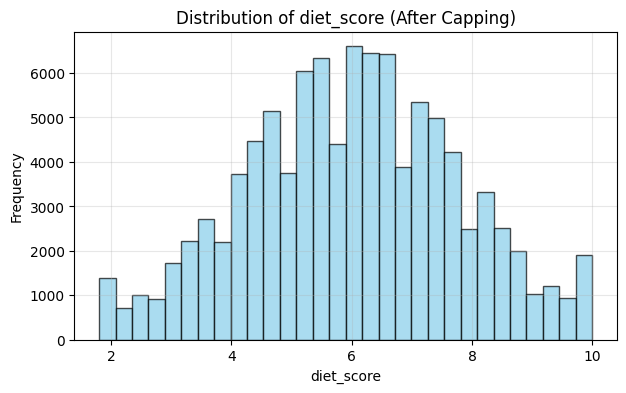

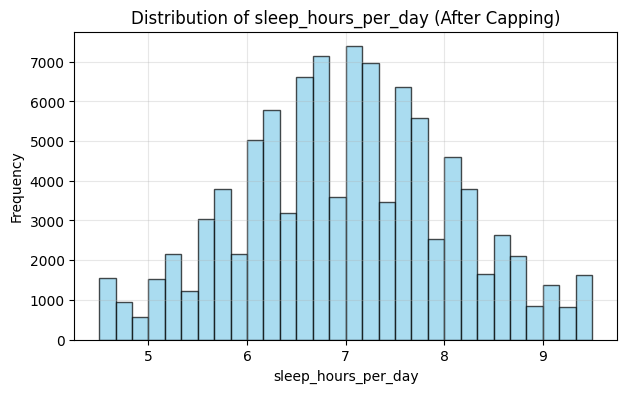

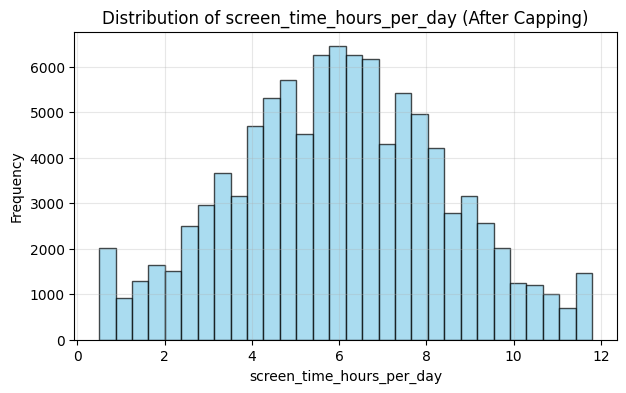

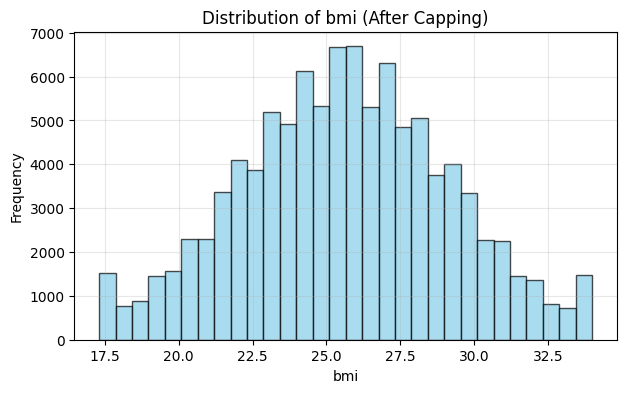

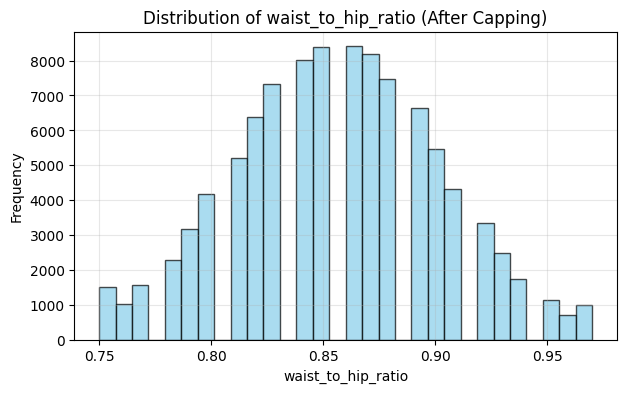

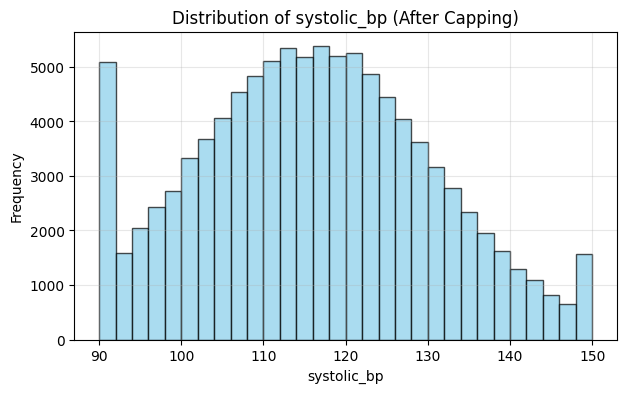

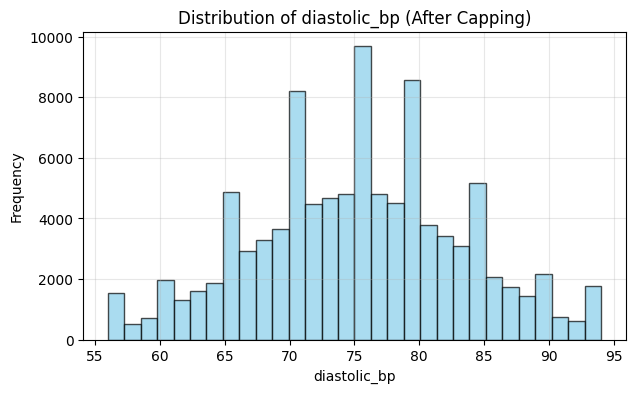

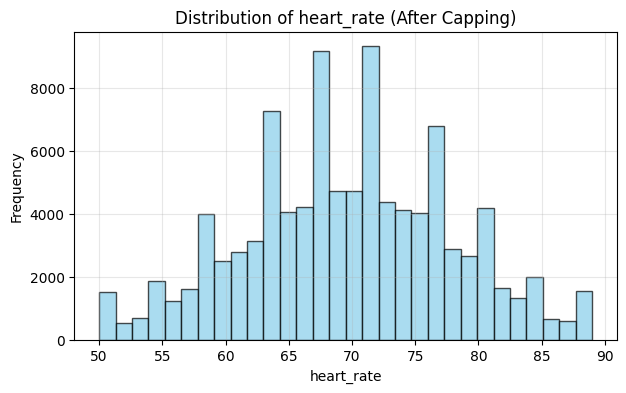

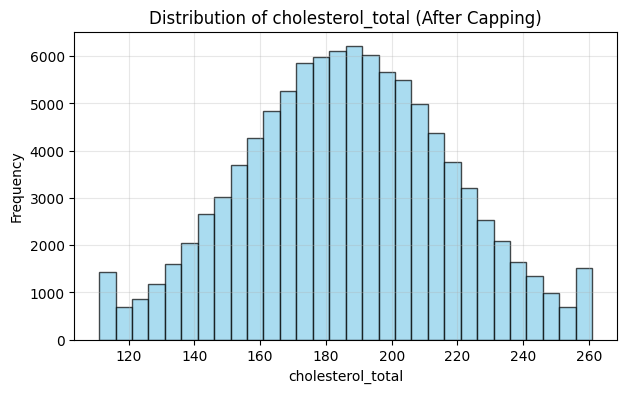

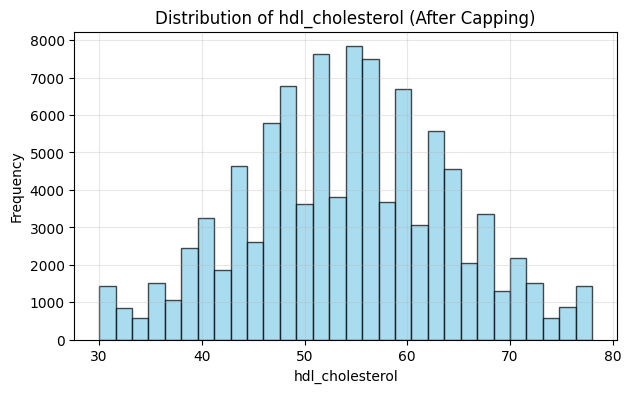

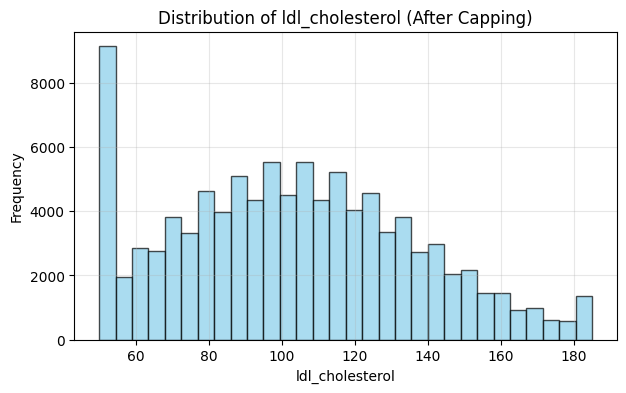

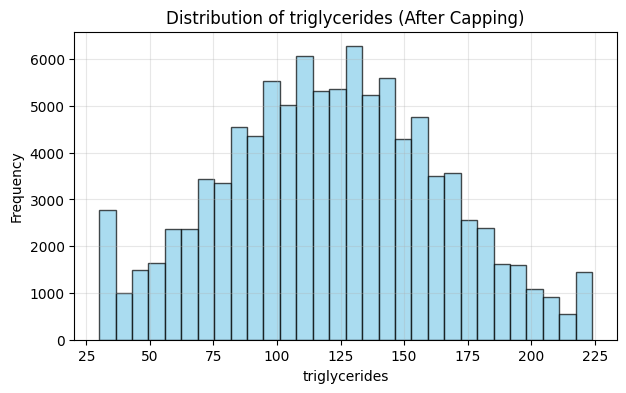

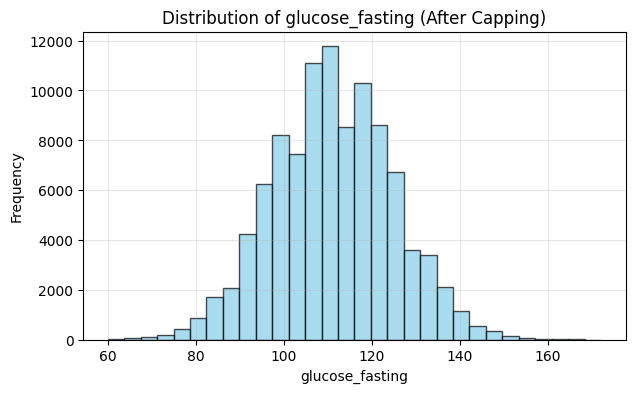

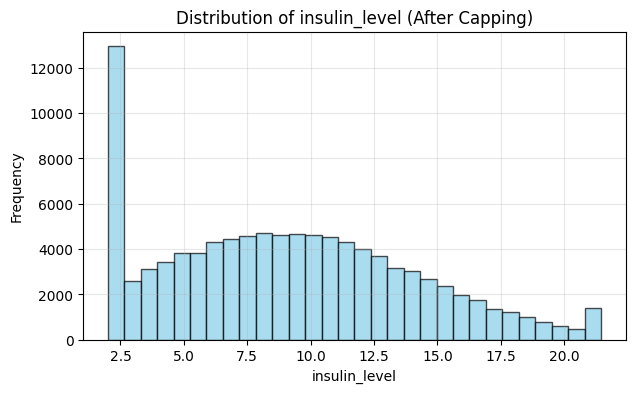

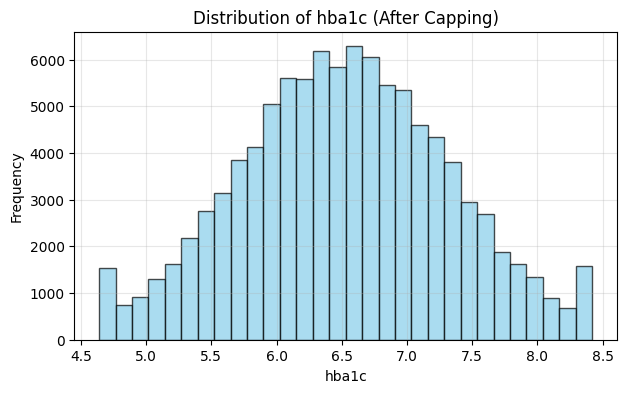

In [14]:
for col in continuous_cols:
    plt.figure(figsize=(7,4))
    plt.hist(data[col], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    plt.title(f'Distribution of {col} (After Capping)')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(alpha=0.3)
    plt.show()

## III. Exploratory Data Analysis

### 1. Phân Tích Dữ Liệu Bằng Truy Vấn SQL Trực Tiếp Trên CSDL SQLite (SQL Exploratory Data Analysis)
**Minh chứng kỹ năng Data Analytics thông qua truy vấn SQL (`pandas.read_sql` & `sqlite3`)**

In [15]:
# SQL 1: Thống kê phân bố 3 nhóm Đường huyết Y khoa (Bình thường / Tiền tiểu đường / Tiểu đường)
sql_query1 = """
SELECT 
    CASE 
        WHEN glucose_fasting < 100 THEN 'Normal (<100 mg/dL)'
        WHEN glucose_fasting BETWEEN 100 AND 125 THEN 'Prediabetes (100-125 mg/dL)'
        ELSE 'Diabetes (>=126 mg/dL)'
    END AS glucose_category,
    COUNT(*) AS patient_count,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM raw_dataset), 2) AS percentage
FROM raw_dataset
GROUP BY glucose_category
ORDER BY patient_count DESC;
"""
df_sql1 = pd.read_sql(sql_query1, conn_sqlite)
print('=== THỐNG KÊ SQL: PHÂN BỐ NHÓM ĐƯỜNG HUYẾT Y KHOA ===')
print(df_sql1)


=== THỐNG KÊ SQL: PHÂN BỐ NHÓM ĐƯỜNG HUYẾT Y KHOA ===
              glucose_category  patient_count  percentage
0  Prediabetes (100-125 mg/dL)          65757       65.76
1          Normal (<100 mg/dL)          19715       19.71
2       Diabetes (>=126 mg/dL)          14528       14.53


In [16]:
# SQL 2: Phân tích Đường huyết & HbA1c trung bình theo Tiền sử gia đình & Bệnh lý nền
sql_query2 = """
SELECT 
    family_history_diabetes,
    hypertension_history,
    cardiovascular_history,
    COUNT(*) AS total_patients,
    ROUND(AVG(glucose_fasting), 2) AS avg_glucose_mg_dL,
    ROUND(AVG(bmi), 2) AS avg_bmi,
    ROUND(AVG(hba1c), 2) AS avg_hba1c_percent
FROM raw_dataset
GROUP BY family_history_diabetes, hypertension_history, cardiovascular_history
ORDER BY avg_glucose_mg_dL DESC;
"""
df_sql2 = pd.read_sql(sql_query2, conn_sqlite)
print('=== THỐNG KÊ SQL: ĐƯỜNG HUYẾT THEO TIỀN SỬ BỆNH LÝ ===')
print(df_sql2)


=== THỐNG KÊ SQL: ĐƯỜNG HUYẾT THEO TIỀN SỬ BỆNH LÝ ===
   family_history_diabetes  hypertension_history  cardiovascular_history  \
0                        1                     1                       1   
1                        1                     0                       1   
2                        1                     1                       0   
3                        1                     0                       0   
4                        0                     1                       1   
5                        0                     0                       1   
6                        0                     1                       0   
7                        0                     0                       0   

   total_patients  avg_glucose_mg_dL  avg_bmi  avg_hba1c_percent  
0             505             121.86    25.84               7.01  
1            1246             121.43    25.73               6.97  
2            5057             120.75    25.72              

In [17]:
# SQL 3: Tương quan chỉ số BMI, HbA1c và Đường huyết đói theo nhóm độ tuổi
sql_query3 = """
SELECT 
    CASE 
        WHEN age < 30 THEN 'Under 30'
        WHEN age BETWEEN 30 AND 50 THEN '30 - 50 years'
        ELSE 'Over 50'
    END AS age_group,
    COUNT(*) AS total_patients,
    ROUND(AVG(bmi), 2) AS avg_bmi,
    ROUND(AVG(hba1c), 2) AS avg_hba1c,
    ROUND(AVG(glucose_fasting), 2) AS avg_glucose
FROM raw_dataset
GROUP BY age_group
ORDER BY avg_glucose DESC;
"""
df_sql3 = pd.read_sql(sql_query3, conn_sqlite)
print('=== THỐNG KÊ SQL: CHỈ SỐ THEO NHÓM ĐỘ TUỔI ===')
print(df_sql3)


=== THỐNG KÊ SQL: CHỈ SỐ THEO NHÓM ĐỘ TUỔI ===
       age_group  total_patients  avg_bmi  avg_hba1c  avg_glucose
0        Over 50           48820    25.88       6.63       113.72
1  30 - 50 years           41178    25.43       6.45       109.35
2       Under 30           10002    25.03       6.30       105.69


### 2. Bar Chart (Biểu đồ cột tần suất)

**Nhận xét phân bổ các biến phân loại:**
* Biểu đồ cột cho thấy sự phân bổ số lượng mẫu trên các nhóm của các biến chữ như giới tính, chủng tộc, học vấn, việc làm, tình trạng hút thuốc.
* Số lượng mẫu phân bổ khá đều giữa các nhóm chính, đảm bảo mô hình không bị lệch dữ liệu (data imbalance) nghiêm trọng ở các đặc trưng nhân khẩu học xã hội này.

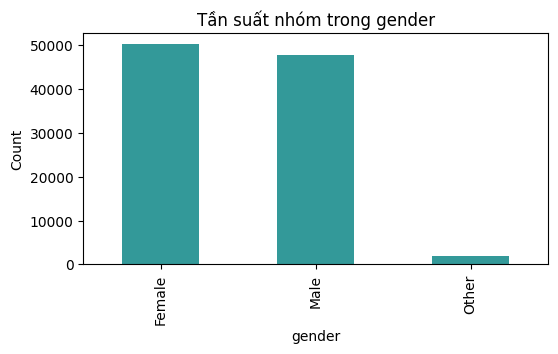

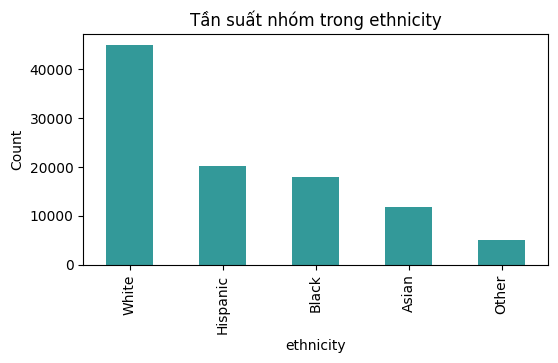

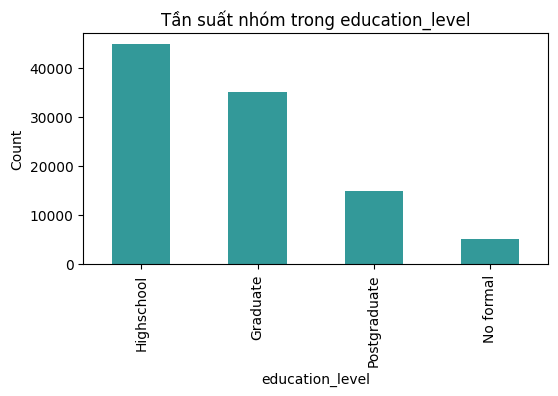

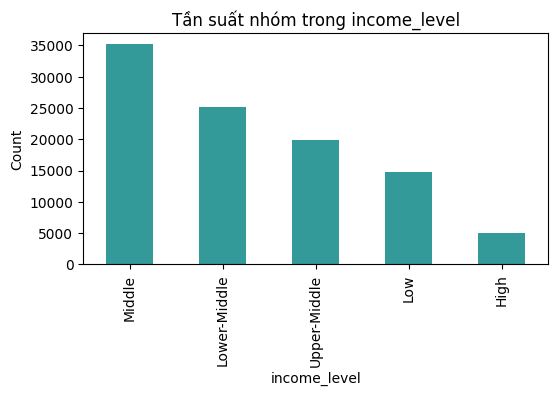

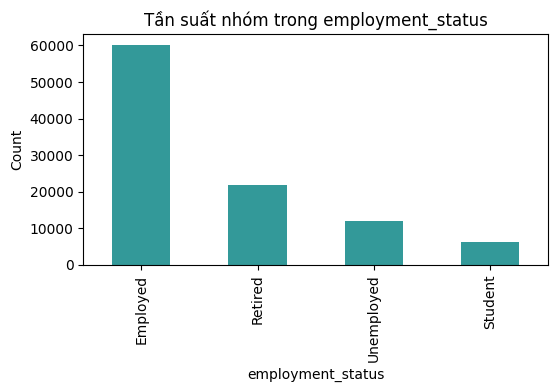

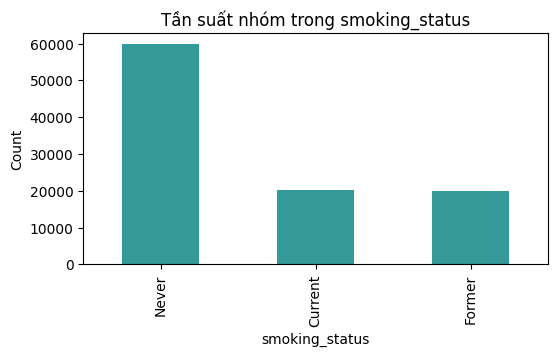

In [18]:
for col in categorical_cols:
    plt.figure(figsize=(6,3))
    data[col].value_counts().plot(kind='bar', color='teal', alpha=0.8)
    plt.title(f"Tần suất nhóm trong {col}")
    plt.ylabel("Count")
    plt.show()

### 3. Encoding (Giai đoạn 3)

In [19]:
# Lưu bản sao dữ liệu gốc trước khi số hóa để dùng cho phân tích ANOVA
data_before_encoding = data.copy()

categorical_cols = data.select_dtypes(include='object').columns
data = pd.get_dummies(data, columns=categorical_cols, drop_first=True, dtype=int)

# Đưa biến mục tiêu glucose_fasting xuống cuối bảng dữ liệu để Heatmap hiển thị ở dưới cùng
target = 'glucose_fasting'
cols = [c for c in data.columns if c != target] + [target]
data = data[cols]
print(f"Kích thước sau khi One-Hot Encode và đưa target về cuối: {data.shape}")

Kích thước sau khi One-Hot Encode và đưa target về cuối: (100000, 39)


### 4. Correlation Heatmap (Mở rộng - 38 cột)

**Phân tích ma trận tương quan mở rộng sau khi đã mã hóa dummy (38 cột):**
* Biến mục tiêu `glucose_fasting` có mối tương quan dương mạnh nhất với `hba1c` ($r = 0.70$), theo sau là `insulin_level` ($r = 0.45$). Đây là điều hoàn toàn phù hợp với thực tế lâm sàng vì HbA1c và Insulin phản ánh trực tiếp trạng thái hóa sinh đường huyết.
* Các yếu tố hành vi lối sống như thời gian xem màn hình (`screen_time`), thời gian vận động (`physical_activity`), điểm chế độ ăn (`diet_score`) có tương quan tuyến tính đơn lẻ rất yếu với đường huyết ($r < 0.1$).
* Giữa các biến độc lập với nhau: Ngoại trừ duy nhất cặp biến hình thể `bmi` và `waist_to_hip_ratio` có tương quan khá mạnh ($r = 0.76$, điều này hoàn toàn hợp lý về mặt y khoa), không xuất hiện cặp biến độc lập nào khác có tương quan vượt quá 0.6. Kiểm chứng định lượng bằng chỉ số VIF ở bước sau cho thấy cả hai biến này đều có VIF dưới 3 (nằm trong khoảng an toàn), do đó chúng không gây đa cộng tuyến nghiêm trọng và được giữ lại để tăng độ chính xác của mô hình.

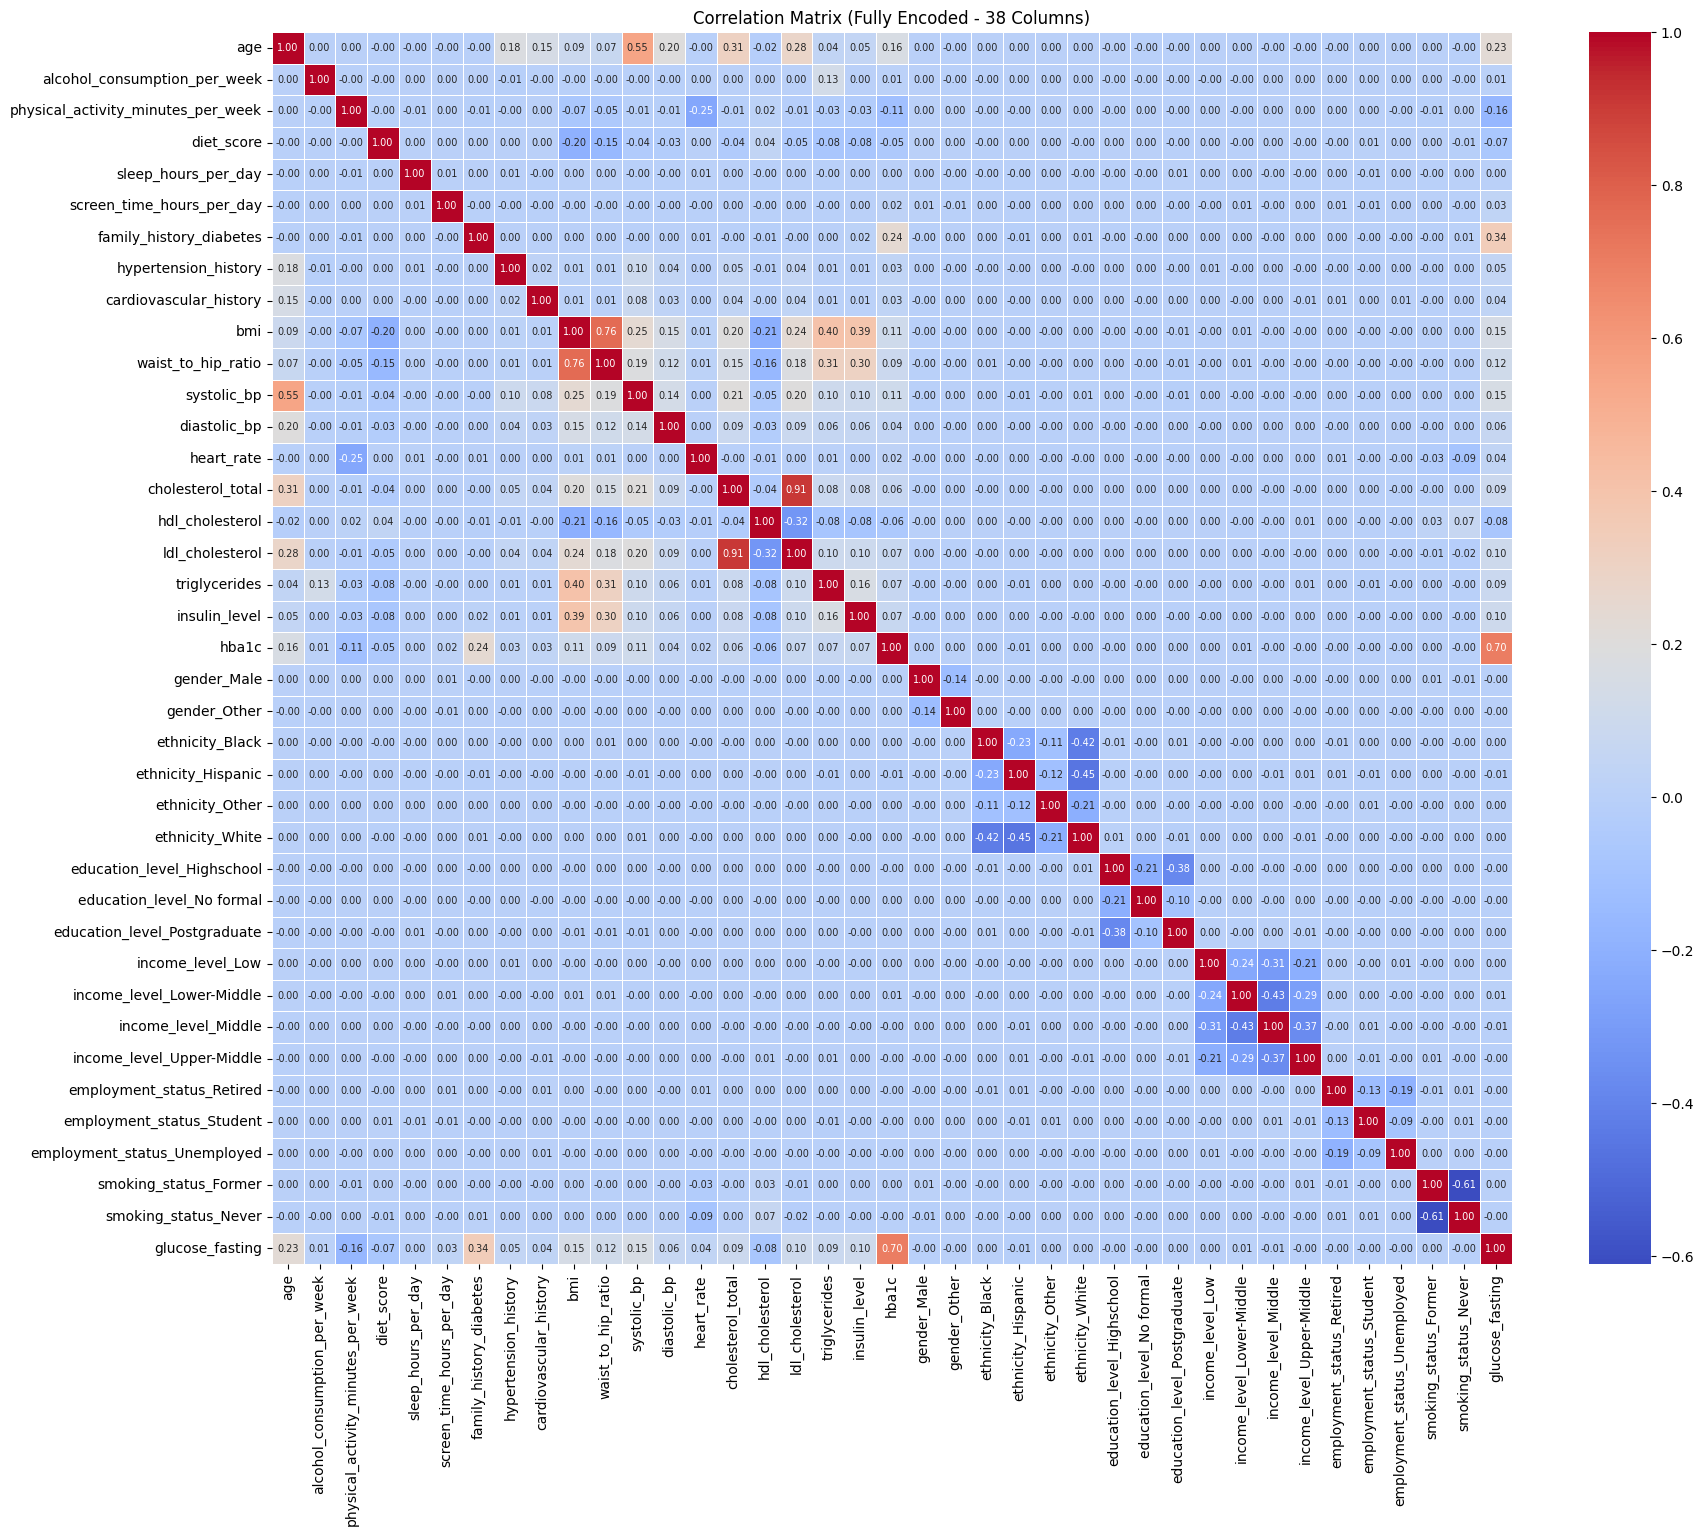

In [20]:
corr = data.corr(numeric_only=True)
plt.figure(figsize=(20,16))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, annot_kws={"size": 7})
plt.title("Correlation Matrix (Fully Encoded - 38 Columns)")
plt.show()

### 5. Đánh giá đa cộng tuyến VIF sau khi vẽ Heatmap

**Phân tích kết quả chạy VIF lần đầu:**
* Chỉ số VIF đo lường mức độ đa cộng tuyến giữa các biến độc lập. Nếu VIF > 10, biến đó bị đa cộng tuyến mạnh và cần loại bỏ.
* Kết quả bảng VIF bên dưới chỉ ra đặc trưng `ldl_cholesterol` có VIF = 10.387 (vượt ngưỡng 10), đồng thời `cholesterol_total` và `diastolic_bp` cũng có VIF rất cao do cộng tuyến tuyến tính với các biến liên quan.

In [21]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Chuẩn bị tập các biến độc lập (loại bỏ target glucose_fasting)
X_vif_raw = data.drop(columns=['glucose_fasting'])
X_vif_raw = sm.add_constant(X_vif_raw.astype(float))
vif_raw_df = pd.DataFrame()
vif_raw_df["Feature"] = X_vif_raw.columns
vif_raw_df["VIF"] = [variance_inflation_factor(X_vif_raw.values, i) for i in range(X_vif_raw.shape[1])]
print("--- BẢNG CHỈ SỐ VIF TRÊN DỮ LIỆU SỐ HÓA BAN ĐẦU ---")
print(vif_raw_df.sort_values(by='VIF', ascending=False).head(15))

--- BẢNG CHỈ SỐ VIF TRÊN DỮ LIỆU SỐ HÓA BAN ĐẦU ---
                      Feature         VIF
0                       const  901.966867
17            ldl_cholesterol   10.417232
15          cholesterol_total    9.494741
32        income_level_Middle    5.208256
31  income_level_Lower-Middle    4.514347
33  income_level_Upper-Middle    3.986376
30           income_level_Low    3.378554
10                        bmi    2.996038
26            ethnicity_White    2.636917
11         waist_to_hip_ratio    2.409099
24         ethnicity_Hispanic    2.153604
23            ethnicity_Black    2.064370
16            hdl_cholesterol    1.913450
38       smoking_status_Never    1.648409
1                         age    1.643270


### 6. Loại bỏ biến đa cộng tuyến và tính toán lại VIF

**Nhận xét sau khi loại bỏ ldl_cholesterol:**
* Sau khi loại bỏ đặc trưng `ldl_cholesterol` (biến duy nhất có VIF > 10), chỉ số VIF của toàn bộ các đặc trưng còn lại (bao gồm cả `cholesterol_total` và `diastolic_bp`) đều **nhỏ hơn 5.3** (nằm hoàn toàn dưới ngưỡng an toàn là 10).
* Dữ liệu lúc này đã hoàn toàn sạch đa cộng tuyến, sẵn sàng đưa vào bước chia train/test và chuẩn hóa.

In [22]:
# Loại bỏ biến ldl_cholesterol bị đa cộng tuyến phát hiện qua kiểm định VIF
data = data.drop(columns=['ldl_cholesterol'])

# Tính toán lại VIF để kiểm chứng
X_vif_clean = data.drop(columns=['glucose_fasting'])
X_vif_clean = sm.add_constant(X_vif_clean.astype(float))
vif_clean_df = pd.DataFrame()
vif_clean_df["Feature"] = X_vif_clean.columns
vif_clean_df["VIF"] = [variance_inflation_factor(X_vif_clean.values, i) for i in range(X_vif_clean.shape[1])]
print("--- BẢNG CHỈ SỐ VIF SAU KHI LOẠI BỎ BIẾN ĐA CỘNG TUYẾN ---")
print(vif_clean_df.sort_values(by='VIF', ascending=False).head(10))

--- BẢNG CHỈ SỐ VIF SAU KHI LOẠI BỎ BIẾN ĐA CỘNG TUYẾN ---
                      Feature         VIF
0                       const  897.145368
31        income_level_Middle    5.208213
30  income_level_Lower-Middle    4.514277
32  income_level_Upper-Middle    3.986351
29           income_level_Low    3.378488
10                        bmi    2.995913
25            ethnicity_White    2.636910
11         waist_to_hip_ratio    2.408992
23         ethnicity_Hispanic    2.153564
22            ethnicity_Black    2.064368


## IV. Data Preprocessing

### 1. Tách X và y

In [23]:
target = "glucose_fasting"
X = data.drop(columns=[target])
y = data[target]

### 2. Chia train/test (Thực hiện khi chuẩn bị train theo Cách A)

In [24]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train size: {X_train.shape}")
print(f"Test size:  {X_test.shape}")

Train size: (80000, 37)
Test size:  (20000, 37)


### 4. Chuẩn hóa đặc trưng liên tục

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
cols_to_scale = [c for c in continuous_cols if c != target and c in X_train.columns]

X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])
print('Hoàn thành chuẩn hóa đặc trưng liên tục về khoảng [0, 1]!')

# Lưu các tập dữ liệu Chuẩn hóa (Normalization) & Splits vào SQLite data/diabetes_pipeline.db
X_train.to_sql('X_train_normalized', conn_sqlite, if_exists='replace', index=False)
X_test.to_sql('X_test_normalized', conn_sqlite, if_exists='replace', index=False)
pd.DataFrame({target: y_train}).to_sql('y_train', conn_sqlite, if_exists='replace', index=False)
pd.DataFrame({target: y_test}).to_sql('y_test', conn_sqlite, if_exists='replace', index=False)
print('Đã lưu các bảng [X_train_normalized], [X_test_normalized], [y_train], [y_test] vào SQLite!')


Hoàn thành chuẩn hóa đặc trưng liên tục về khoảng [0, 1]!
Đã lưu các bảng [X_train_normalized], [X_test_normalized], [y_train], [y_test] vào SQLite!
